WigglRoom Research | Aerospace and Weather<br>
Jeremy Barton<br>
April 10, 2026

### High Point Monument Exporatory Data Analaysis

#### Introduction

High Point, NJ is the highest point in the state of New Jersey with an elevation of about 1,803 feet. On a mostly cloudy day a field operation was conducted to collect aircraft data and to test the radio funcationalities of the WigglWare program at the base of the High Point monument.

The test was sucessful and as expected many more aircrafts were detected during this analysis than in inital testing in a residential area. This notebook will go through cleaning the data for ML processing and applying a physics formula for predicting short term trajectory using LinearRegression as a bassline model.

#### Imports & Preprocessing

In [3]:
# Imports and preprocessing
import sqlite3
import pandas as pd
import matplotlib
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

Connecting to the database, called `aircraft_data.db`. All information collected during the session was added directly to this database, and all data added to the database will be directly added to a pandas dataframe.

In [4]:
# Querying the aircraft table
conn = sqlite3.connect("/home/nunya/Documents/GitHub/wigglroom-research/HighPoint-NJ/041426/aircraft_data_041426.db")
aircraft_df = pd.read_sql_query("SELECT * FROM aircraft", conn)
aircraft_df.head(3)

,id,fetched_at,icao24,callsign,origin_country,latitude,longitude,altitude_ft,on_ground,speed_kts,heading,vertical_rate_fpm,squawk
0,1,2026-04-14T16:58:55.529537147+00:00,a9db6c,N734RP,,40.937164,-74.486877,2600.0,0,80.1,299.12,NaN,1200
1,2,2026-04-14T16:58:55.529537147+00:00,aaaa11,N7866Y,,41.066476,-74.398290,3600.0,0,126.8,342.57,NaN,1200
2,3,2026-04-14T16:58:55.529537147+00:00,aa7f8c,N776CJ,,40.904660,-74.390113,2975.0,0,280.9,46.88,NaN,6614


#### Data Cleaning

Replace all rows that have no callsign with "NO CALLSIGN".

In [5]:
aircraft_df['callsign'] = aircraft_df['callsign'].replace("", "UNKNOWN")

How many unique aircrafts?

In [6]:
unq = aircraft_df['callsign'].nunique()
print(f"There were {unq} unique aircrafts in this analysis.")

# nunique)() returns a single number
#   which is a count of distinct values
#   it also excludes duplicates and ignores NaN values

There were 225 unique aircrafts in this analysis.


Which aircrafts have coordinates?

In [7]:
aircraft_df = aircraft_df[
    aircraft_df['longitude'].notna() &
    aircraft_df['latitude'].notna()
]

print(f"There were {aircraft_df['callsign'].nunique()} aircrafts with coordinates.")


There were 98 aircrafts with coordinates.


Which aircrafts have a callsign?

In [8]:
aircraft_df = aircraft_df[
aircraft_df['callsign'] != 'UNKNOWN'
]

aircraft_df['callsign'].nunique()

97

#### EDA

What was the max speed of aircrafts with coordinates?

In [9]:
max_idx = aircraft_df['speed_kts'].idxmax()
max_row = aircraft_df.loc[max_idx]

print(f"Fastest flying aircraft was callsign {max_row['callsign']} at {max_row['speed_kts']} ft")

Fastest flying aircraft was callsign SWA541 at 510.8 ft


What was the highest flying aircraft with coordinates?

In [10]:
max_idx = aircraft_df['altitude_ft'].idxmax()
max_row = aircraft_df.loc[max_idx]

print(f"Highest flying aircraft was callsign {max_row['callsign']} at {max_row['altitude_ft']} ft")

Highest flying aircraft was callsign ASP565 at 45000.0 ft


What are the callsigns and max speed of the top 10 aircrafts?

In [11]:
top10 = (
    aircraft_df.groupby('callsign', as_index=False)
    .agg({
        'altitude_ft': 'max',
        'speed_kts': 'max'
    })
    .sort_values(by='altitude_ft', ascending=False)
    .head(10)
)

top10

,callsign,altitude_ft,speed_kts
7,ASP565,45000.0,386.4
9,DAL223,40000.0,425.0
84,SWA541,37000.0,510.8
2,AAL1909,36325.0,474.4
4,AAL785,36000.0,452.3
96,UAL947,36000.0,412.8
6,ADB779F,35000.0,483.8
57,N600XT,33250.0,253.6
83,SWA1372,33000.0,473.1
31,JBU1492,28650.0,472.7


Which aircraft do we have the most data for?

In [12]:
aircraft_df['callsign'].value_counts().head(1)

callsign
N36JZ    620
Name: count, dtype: int64

How long was the analysis?

In [13]:
import pandas as pd

# Convert column to proper datetime type
aircraft_df['fetched_at'] = pd.to_datetime(aircraft_df['fetched_at'])

# Get max and min timestamps
max_time = aircraft_df['fetched_at'].max()
min_time = aircraft_df['fetched_at'].min()

# Time difference (duration between first and last record)
time_diff = max_time - min_time

max_time, min_time, time_diff

(Timestamp('2026-04-14 17:09:42.379855460+0000', tz='UTC'),
 Timestamp('2026-04-14 16:58:55.529537147+0000', tz='UTC'),
 Timedelta('0 days 00:10:46.850318313'))

### Predicting Trajectory with Physics Models and Linear Regression

Using aircraft heading, speed, and vertical rate to compute physics-based predicted positions, then training a linear regression model to learn the **correction error** — the difference between the physics prediction and actual future position.

#### 1) Sort by callsign and time, then compute future positions

In [14]:
# Sort by callsign so future-row lookups are in order
aircraft_df = aircraft_df.sort_values(['callsign', 'fetched_at']).reset_index(drop=True)

<b>On Ground Truths</b><br>
Since this is supervised learning, we need real outcomes to learn from. During training, the model needs to know the answer for every row. The following shift provides that answer by looking at the next row's recorded position.

In [15]:
# Shift lat/lon/alt by 1 row within each callsign group to get the next observed position
aircraft_df['lat_future']  = aircraft_df.groupby('callsign')['latitude'].shift(-1)
aircraft_df['lon_future']  = aircraft_df.groupby('callsign')['longitude'].shift(-1)
aircraft_df['alt_future']  = aircraft_df.groupby('callsign')['altitude_ft'].shift(-1)

Next we'll need to compute time delta between rows, which requires us to calculate the difference in seconds, grouped by `callsign` (to track the unit) and `fetched_at` to access the timestamp.

In [16]:
# Compute actual time delta between rows (in seconds)
aircraft_df['dt'] = (
    aircraft_df.groupby('callsign')['fetched_at']
    .diff()
    .shift(-1)
    .dt.total_seconds()
)

# Drop rows with no future position (last row of each aircraft)
aircraft_df = aircraft_df.dropna(subset=['lat_future', 'lon_future', 'alt_future', 'dt'])
aircraft_df = aircraft_df[aircraft_df['dt'] > 0].reset_index(drop=True)

print(f"Rows available for modeling: {len(aircraft_df)}")

Rows available for modeling: 24344


#### 2) Compute velocity components from heading and speed

Decompose the aircraft's speed into x (East/West) and y (North/South) components using trigonometry.

<b>Explaination:</b> An aircraft flying at a heading and speed is moving in one diagonal direction. Trigonometry lets us split that into two independent components, how fast it's moving East/West (vx) and how fast it's moving North/South (vy).

If we were to feed `speed_kts` and `heading` directly into the model, it would have to figure out the trigonometry by itself. LinearRegression cannot do this. By decomposing first, the data is being translated into pre-computed linear values the model can work with.

In [17]:
# Convert heading degrees to radians
aircraft_df['heading_rad'] = np.deg2rad(aircraft_df['heading'])

# Decompose speed into directional components
aircraft_df['vx'] = aircraft_df['speed_kts'] * np.cos(aircraft_df['heading_rad'])
aircraft_df['vy'] = aircraft_df['speed_kts'] * np.sin(aircraft_df['heading_rad'])

aircraft_df[['callsign', 'speed_kts', 'heading', 'vx', 'vy']].head(5)

,callsign,speed_kts,heading,vx,vy
0,AAL1189,415.8,37.48,329.964655,253.007838
1,AAL1189,415.8,37.48,329.964655,253.007838
2,AAL1189,415.8,37.48,329.964655,253.007838
3,AAL1189,415.8,37.48,329.964655,253.007838
4,AAL1189,415.8,37.48,329.964655,253.007838


#### 3) Physics prediction

Using `position + velocity × time`, the simplest kinematic model, to predict where the aircraft should be next if it flew perfectly straight. This will be one of multiple prediction methods that would be used.

In [18]:
# Physics-based next position prediction (kinematic model)
aircraft_df['lat_phys'] = aircraft_df['latitude']      + aircraft_df['vx'] * aircraft_df['dt']
aircraft_df['lon_phys'] = aircraft_df['longitude']     + aircraft_df['vy'] * aircraft_df['dt']
aircraft_df['alt_phys'] = aircraft_df['altitude_ft']   + aircraft_df['vertical_rate_fpm'] * aircraft_df['dt']

aircraft_df[['callsign', 'lat_phys', 'lon_phys', 'alt_phys']].head(5)

,callsign,lat_phys,lon_phys,alt_phys
0,AAL1189,401.684707,202.885686,24000.0
1,AAL1189,402.423655,203.452567,24000.0
2,AAL1189,399.723783,201.382589,24000.0
3,AAL1189,400.686585,202.120839,24000.0
4,AAL1189,398.098058,200.137181,24000.0


#### 4) Compute the correction error (ML targets)

The core idea of this section is to enhance the physics model by adding errors that explain by <b>how much was the physics model wrong?</b>. This information is what the prediction model will learn from.

This is also where the physics and ML model meet, but physics does most of the heavy lifting because the model just needs to learn the small systematic biases that "assuming an aircraft will will perfectly straight" that the physics model will consistently get wrong. These variables could include wind speed, terrain data or other environmental factors.

In [19]:
# ML targets: the correction the model needs to learn
aircraft_df['error_lat'] = aircraft_df['lat_future'] - aircraft_df['lat_phys']
aircraft_df['error_lon'] = aircraft_df['lon_future'] - aircraft_df['lon_phys']
aircraft_df['error_alt'] = aircraft_df['alt_future'] - aircraft_df['alt_phys']

print("Error stats (physics correction targets):")
aircraft_df[['error_lat', 'error_lon', 'error_alt']].describe().round(4)

Error stats (physics correction targets):


,error_lat,error_lon,error_alt
count,24234.0000,24234.0000,17273.0000
mean,12.4623,-59.1421,-11.8634
std,710.6027,468.6861,1323.0400
min,-77743.9792,-42493.2325,-8491.3282
25%,-171.6367,-200.8672,-269.3326
50%,62.1522,-100.7144,64.1653
75%,165.5936,93.6836,852.8210
max,710.8002,389.0044,4008.6611


#### 5) Build feature matrix and perform train/test split

In order for the ML model to read the data, it needs to be split between training and testing data. The training data is used to teach the model on the existing data, and the testing data acts like unseen data the model would predict.

If the model were evaluated on the same data it trained on, it would appear to perform perfectly abd would have simply memorized the answers rather than learning to generalize. The test set acts as a reality check on data the model has never seen, giving a honest measure of how well it would perform on new aircraft.

In [20]:
# Features: current state and physics predictions
feature_cols = [
    'latitude', 'longitude', 'altitude_ft',
    'vx', 'vy', 'vertical_rate_fpm',
    'lat_phys', 'lon_phys', 'alt_phys'
]

# This is the data we are predicting
targets = ['error_lat', 'error_lon', 'error_alt']

# 
# Drop rows with any NaN in features or targets
ml_df = aircraft_df[feature_cols + targets].dropna().reset_index(drop=True)

X = ml_df[feature_cols]
y = ml_df[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"X_train size is {X_train.shape} values.")
print(f"y_train size is {y_train.shape} values. The 3 correction targets (error_lat, error_lon, error_alt).")
print(f"X_test  size is {X_test.shape} values.")
print(f"y_test  size is {y_test.shape} values.")

X_train size is (13818, 9) values.
y_train size is (13818, 3) values. The 3 correction targets (error_lat, error_lon, error_alt).
X_test  size is (3455, 9) values.
y_test  size is (3455, 3) values.


#### Step 6: Train a Linear Regression model

A Linear Regression model is the standard baseline to compare with other models.

In [21]:
# Train linear regression
ols = LinearRegression()
model = ols.fit(X_train, y_train)

print("Model coefficients per target:")
for i, target in enumerate(targets):
    coef_dict = dict(zip(feature_cols, ols.coef_[i]))
    print(f"\n{target}:")
    for feat, coef in coef_dict.items():
        print(f"  {feat:30s}: {coef:.6f}")

Model coefficients per target:

error_lat:
  latitude                      : 0.999894
  longitude                     : -0.000003
  altitude_ft                   : 0.000001
  vx                            : 0.000002
  vy                            : -0.000002
  vertical_rate_fpm             : 0.000001
  lat_phys                      : -0.999997
  lon_phys                      : 0.000002
  alt_phys                      : -0.000001

error_lon:
  latitude                      : -0.000034
  longitude                     : 1.000051
  altitude_ft                   : -0.000000
  vx                            : 0.000000
  vy                            : 0.000005
  vertical_rate_fpm             : -0.000000
  lat_phys                      : -0.000000
  lon_phys                      : -0.999999
  alt_phys                      : 0.000000

error_alt:
  latitude                      : -0.039196
  longitude                     : 1.612145
  altitude_ft                   : 0.993495
  vx                

#### Translating back to coordinates

To get the predicted coordinated, the predictions will be added back into the physics prediction. This will return the final real-world coordinate.

The physics model provides you the base position, and the ML model refines it. We always need both working together to get a usable real-world coordinate.

In [23]:
# Get physics prediction for a specific aircraft
aircraft = aircraft_df[aircraft_df['callsign'] == 'N36JZ'].iloc[-1]  # last known row

# Build the feature row the model expects
row = aircraft[feature_cols].values.reshape(1, -1)

# Model predicts the correction
correction = ols.predict(row)[0]  # returns [error_lat, error_lon, error_alt]

# Add correction to physics prediction to get final coordinates
final_lat = aircraft['lat_phys'] + correction[0]
final_lon = aircraft['lon_phys'] + correction[1]
final_alt = aircraft['alt_phys'] + correction[2]

print(f"Predicted next position for {aircraft['callsign']}:")
print(f"  Latitude:  {final_lat:.6f}")
print(f"  Longitude: {final_lon:.6f}")
print(f"  Altitude:  {final_alt:.0f} ft")

Predicted next position for N36JZ:
  Latitude:  40.995180
  Longitude: -73.693088
  Altitude:  5458 ft


/home/nunya/Documents/GitHub/wigglroom-research/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#### 7) Evaluate R², RMSE, and MAE

#### R2 Score

The R2 score explains how well the model explains the variance in the targer variable. It answers the question "How much better is the model than random guessing?"

In [24]:
# R2 Score
r2_train = ols.score(X_train, y_train)
r2_test  = ols.score(X_test,  y_test)

print(f"R2 score for training data : {r2_train:.4f}")
print(f"R2 score for testing data  : {r2_test:.4f}")

R2 score for training data : 0.9998
R2 score for testing data  : 0.9997


A score of 1.0 means the model expalins 100% of the variance. 0.0 explains none of the variance, basically the same as predicting the mean itself. Anything less than zero means the model is actually <b>worse</b> than predicing the average.

#### RMSE Score

RMSE measures the average error between predicted and actual values, but penalizes large errors more heavily because the differences are squared before averaging

In [25]:
# RMSE
rmse_train = root_mean_squared_error(y_train, ols.predict(X_train))
rmse_test  = root_mean_squared_error(y_test,  ols.predict(X_test))

print(f"Train RMSE: {rmse_train:.6f}")
print(f"Test  RMSE: {rmse_test:.6f}")

Train RMSE: 9.994640
Test  RMSE: 13.124509


How we read the RMSE score depeneds on how the target variable is measured, since RMSE measures the average prediction in the same units as the target variable. Context is everything. For example, and RMSE of 5 is great if the target ranges from 0 to 1000, but terrible if it ranges 0-6.

An RMSE score should be compared with the mean to understand it it is < 10% of the range, or with other RMSE scores from other  models. The model with the lower RMSE fits better.

#### MAE Score

MAE (Mean Absolute Error) measures the average error between predicted and actual values, treating all errors equally regardless of size.

In [26]:
# MAE
mae_train = mean_absolute_error(y_train, ols.predict(X_train))
mae_test  = mean_absolute_error(y_test,  ols.predict(X_test))

print(f"MAE for training data: {mae_train:.6f}")
print(f"MAE for testing data : {mae_test:.6f}")

MAE for training data: 4.641625
MAE for testing data : 4.855825


MAE treats all errors equally as it is simply the average absolute error across all predictions.

This is a good balance from RMSE since it punishes larger errors more (since the errors are squared before averaging).

#### Comparing RMSE and MAE

The closer an RMSE score is to its MAE means most errors are in similar size. This could mean the model was consistently right, or wrong, accross all predictions.

When RMSE is much larger than MAE, this means a few predictions are very off, even if the majority are decent.

### Visualizing the Learning Curve

The learning curve shows how model performance (R²) changes as more training data is used.

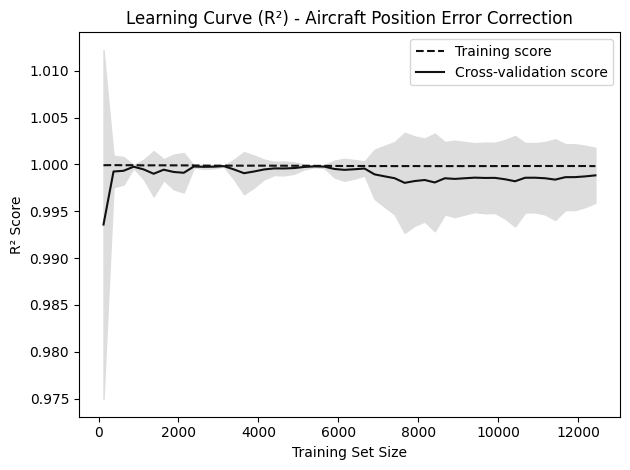

In [27]:
# Create feature matrix and target vector for learning curve
features_lc, target_lc = X_train, y_train

# Compute learning curve across 50 evenly spaced training set sizes
train_sizes, train_scores, test_scores = learning_curve(
    # Linear Regression model
    LinearRegression(),
    # Feature matrix
    features_lc,
    # Target vector
    target_lc,
    # Number of folds
    cv=10,
    # Performance metric - R2
    scoring='r2',
    # Use all computer cores
    n_jobs=1,
    # 50 evenly spaced training set sizes from 1% to 100%
    train_sizes=np.linspace(0.01, 1.0, 50)
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores,  axis=1)

test_mean  = np.mean(test_scores,  axis=1)
test_std   = np.std(test_scores,   axis=1)

# Plot the learning curve
plt.plot(train_sizes, train_mean, '--', color="#111111", label="Training score")
plt.plot(train_sizes, test_mean,        color="#111111", label="Cross-validation score")

plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, color="#DDDDDD")
plt.fill_between(train_sizes, test_mean - test_std,
                 test_mean + test_std, color="#DDDDDD")

plt.title("Learning Curve (R²) - Aircraft Position Error Correction")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()